## Оценка вероятностей ошибок

Мы разобрались со всеми основными параметрами дизайна, которые нужны для запуска эксперимента.\
Но что если мы где-то совершили ошибку и вероятность принять неверное решение больше (или меньше), чем мы ожидаем?\
Проверить правильность дизайна можно с помощью синтетических экспериментов на исторических данных.\
Эксперименты называются синтетическими, потому что они не проводятся на самом деле, а моделируются численно.\
Разберёмся, как это делается.

## A/A эксперимент на исторических данных

У нас есть данные о продажах за прошлую неделю. Представьте, что мы вернулись в прошлое и хотим запустить наш эксперимент на прошлой неделе.\
Выберем группы и обработаем данные согласно нашему дизайну. В итоге мы должны вынести вердикт, есть статистически значимые отличия или нет.\
Повторим это 1000 раз с разными способами разбиения людей на группы.\
Получим 1000 вердиктов, есть значимые отличия или нет. Такое моделирование можно проводить на разных исторических периодах времени.

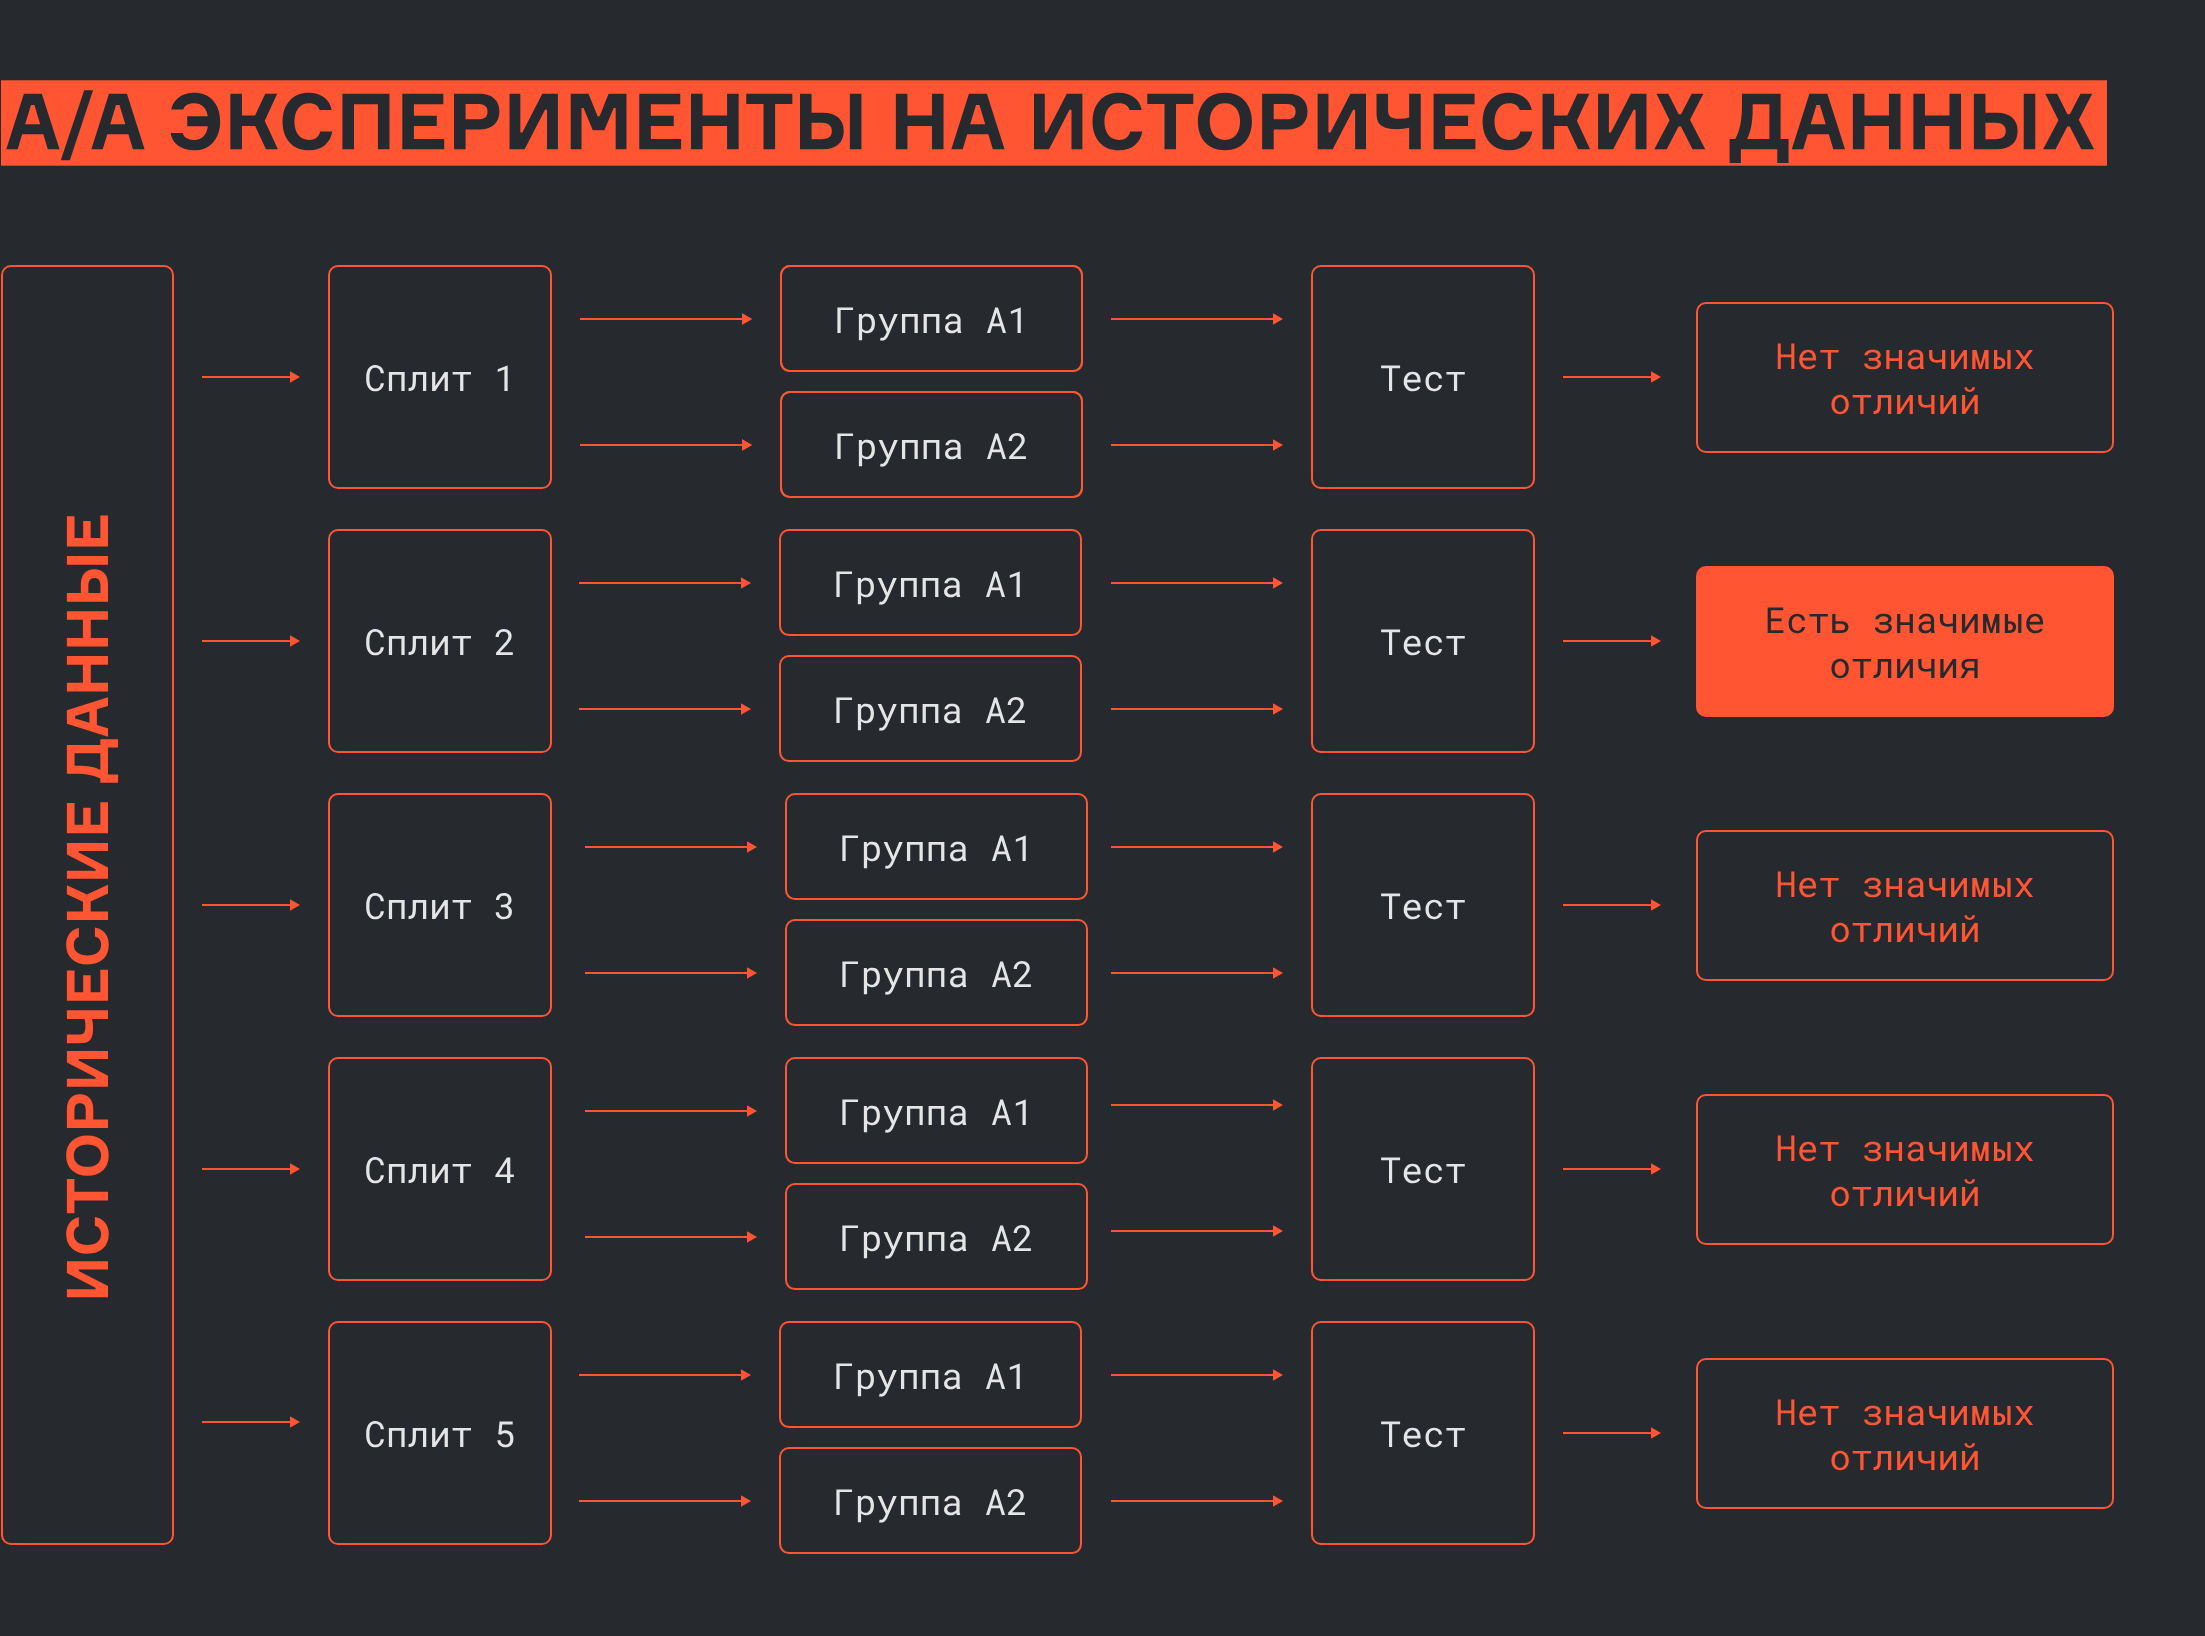

Мы знаем, что эффекта на самом деле нет, так как мы не запускали эксперимент на прошлой неделе и группы выбирали случайным образом.\
Доля экспериментов, в которых был обнаружен значимый эффект — это оценка вероятности ошибки первого рода.\
Если в дизайне эксперимента уровень значимости равен 0.05, то из 1000 экспериментов примерно в 50 должен быть найден значимый эффект.\
Такие эксперименты называются А/А экспериментами, так как у нас обе группы контрольные и никакое воздействие не оказывается.

### Вопрос:
Если мы выбрали уровень значимости 0,2 и провели 500 A/A экспериментов на исторических данных, то в каком числе случаев мы ожидаем «обнаружить» значимое отличие?

***Ответ:*** 100\
Ожидаемое количество экспериментов со значимыми отличиями равно произведению количества экспериментов на вероятность ошибки первого рода, которая равна уровню значимости: `0,2*500=100`

## A/B эксперимент на исторических данных

Аналогично можно оценить вероятность ошибки второго рода. Для этого нужно также провести 1000 синтетических экспериментов на исторических данных, но с одним отличием:\
в экспериментальную группу нужно искусственно добавить эффект, равный ожидаемому эффекту.\
Это можно делать разными способами, самый простой — добавить значение эффекта ко всем значениям экспериментальной группы.\
То есть, если человек из экспериментальной группы на прошлой неделе совершил покупок на 784 рубля, а ожидаемый эффект 5 рублей, то новое значение будет 789 рублей.

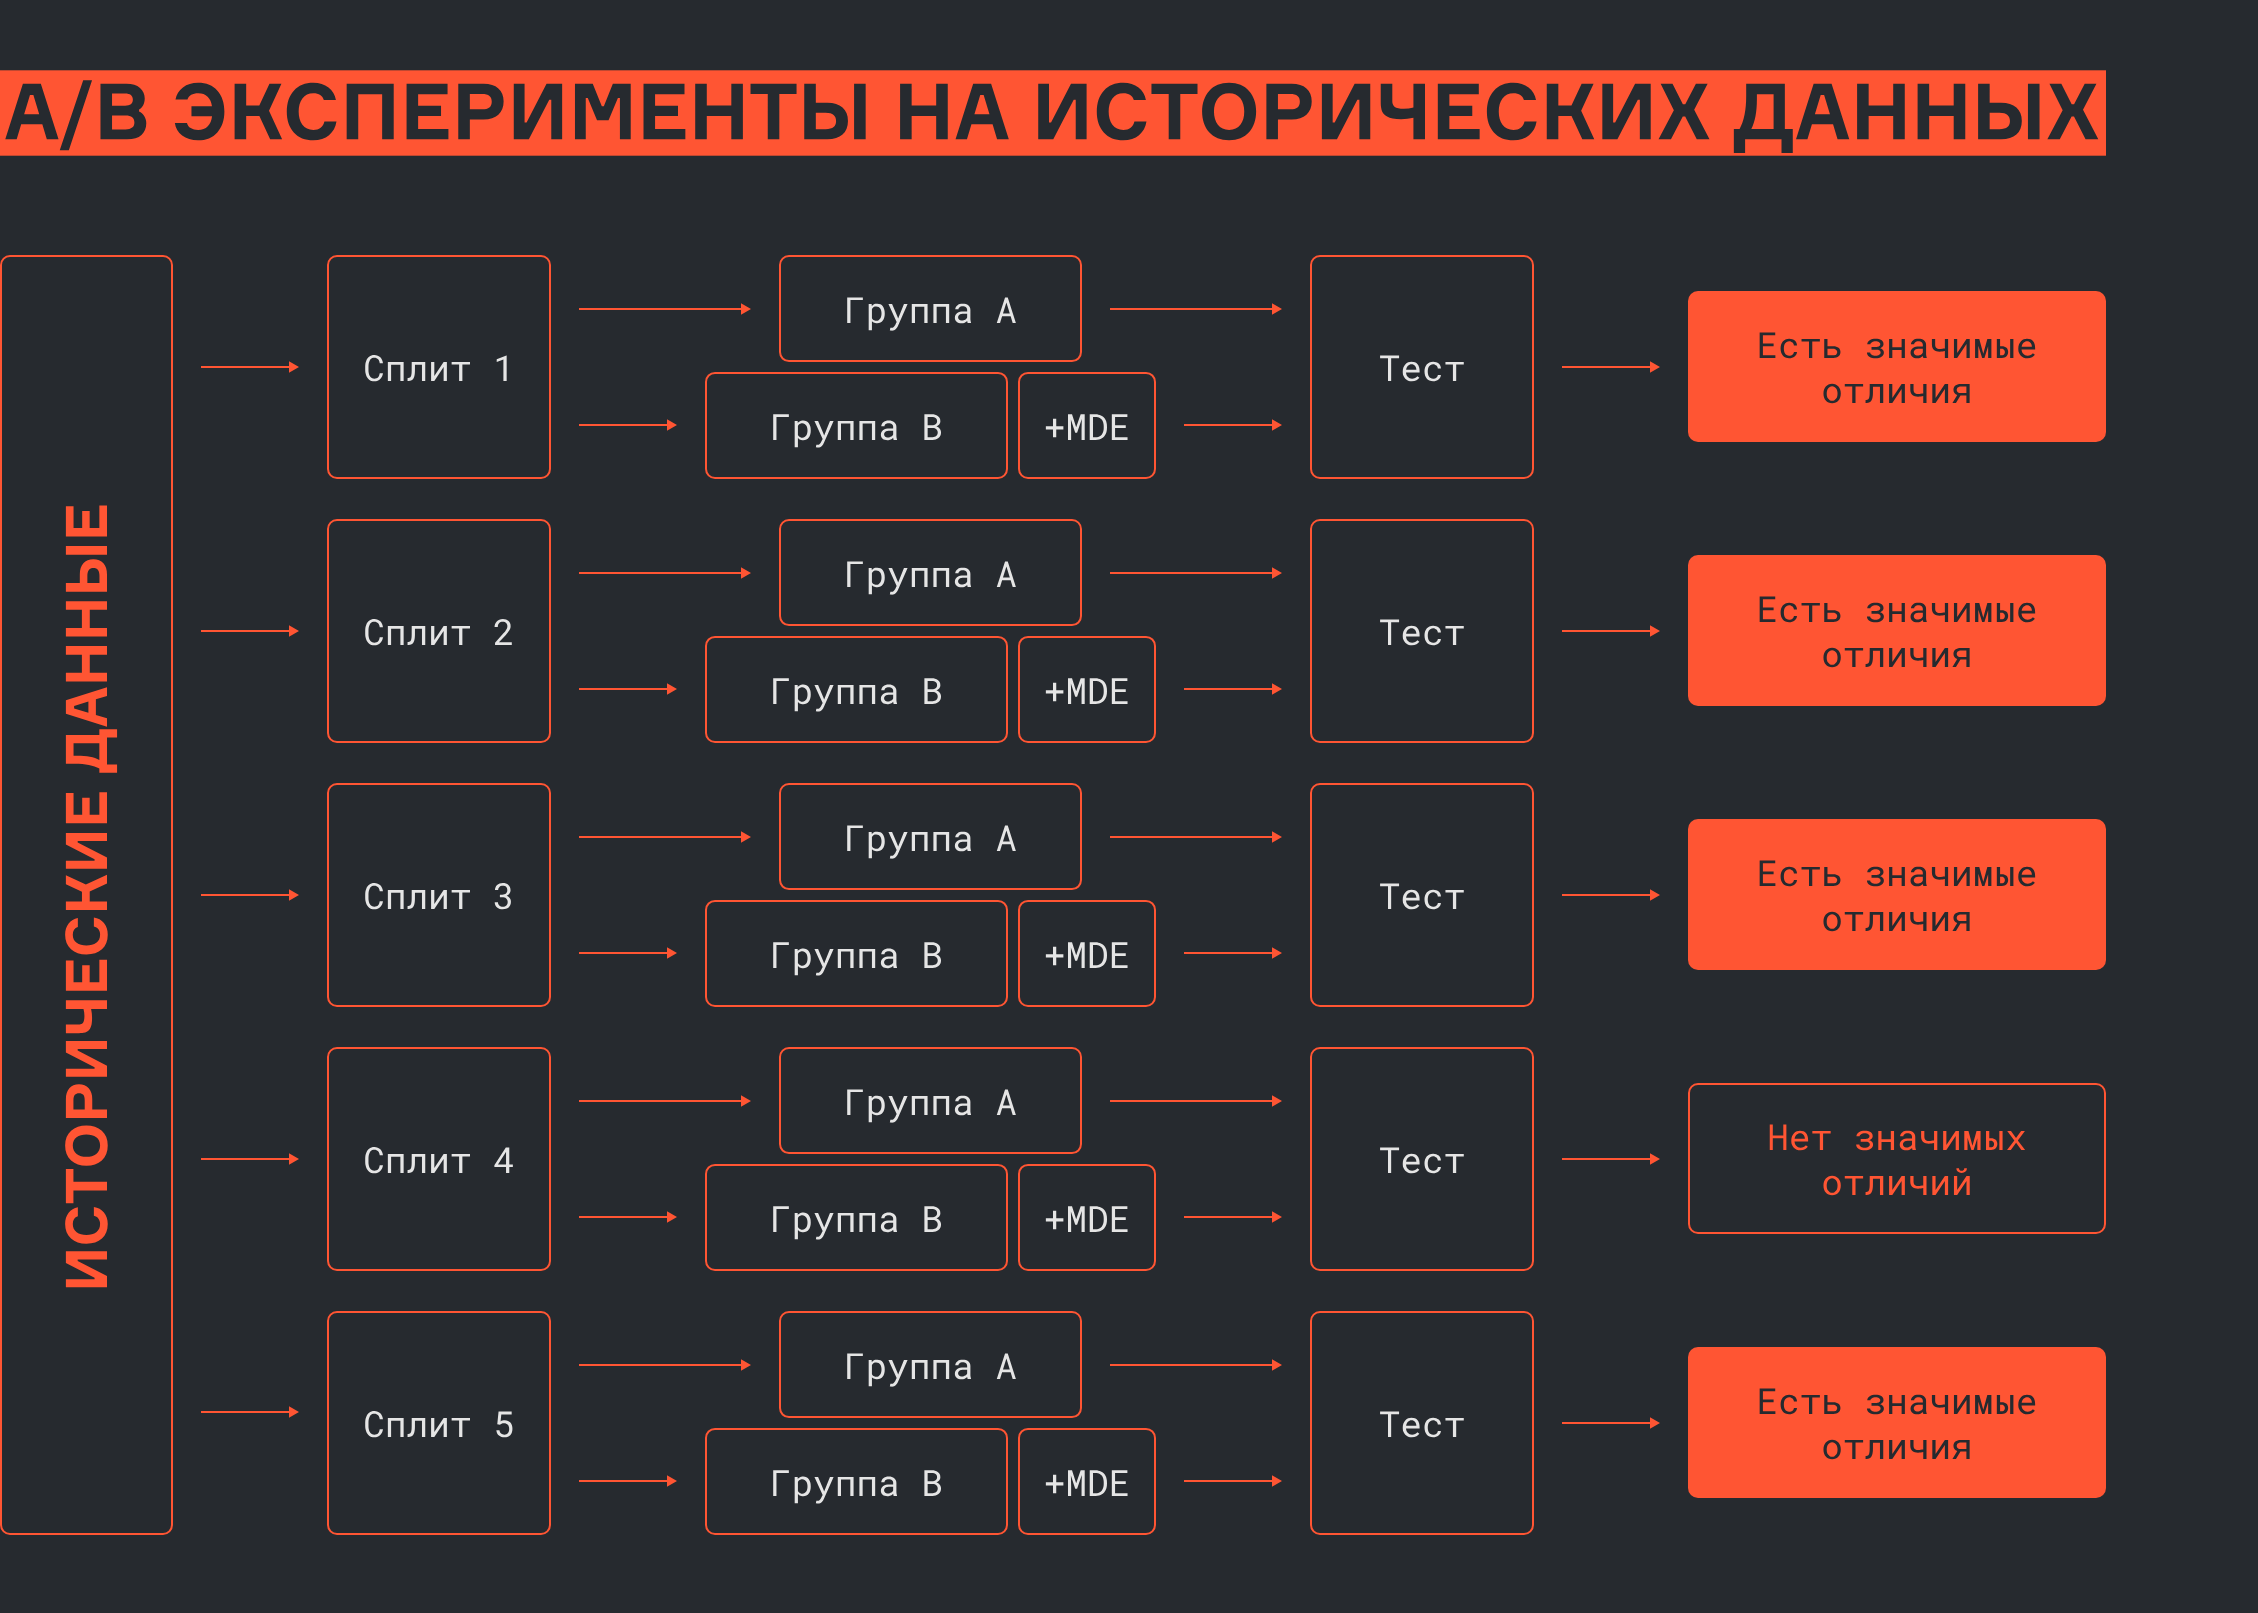

Далее оцениваем эффект согласно дизайну. В итоге получаем также 1000 вердиктов. Но теперь эффект на самом деле есть.\
Доля экспериментов, в которых значимые отличия не были найдены — это оценка вероятности ошибки второго рода.\
Оценка вероятности ошибки второго рода должна быть не больше допустимой вероятности ошибки второго рода, указанной в дизайне эксперимента.\
Для выбранного MDE и фиксированной мощности 0.9 (вероятность ошибки II рода 0.1) примерно в 100 случаях из 1000 ожидается ошибка второго рода, то есть критерий утверждает, что эффекта нет, хотя на самом деле эффект есть, и в 900 случаях из 1000 ожидается обнаружение эффекта.

## Проверка дизайна эксперимента на платформе

Для дизайна эксперимента на платформе A/B тестирования есть вкладка Дизайн.\
Если открыть её и отправить запрос с параметрами по умолчанию, то получится результат примерно как на картинке ниже.\
Справа в таблице есть оценки вероятностей ошибок. Они получены способом, который мы только что обсудили.\
Также там есть оценка необходимого размера групп, которая вычисляется по формуле из прошлого урока.

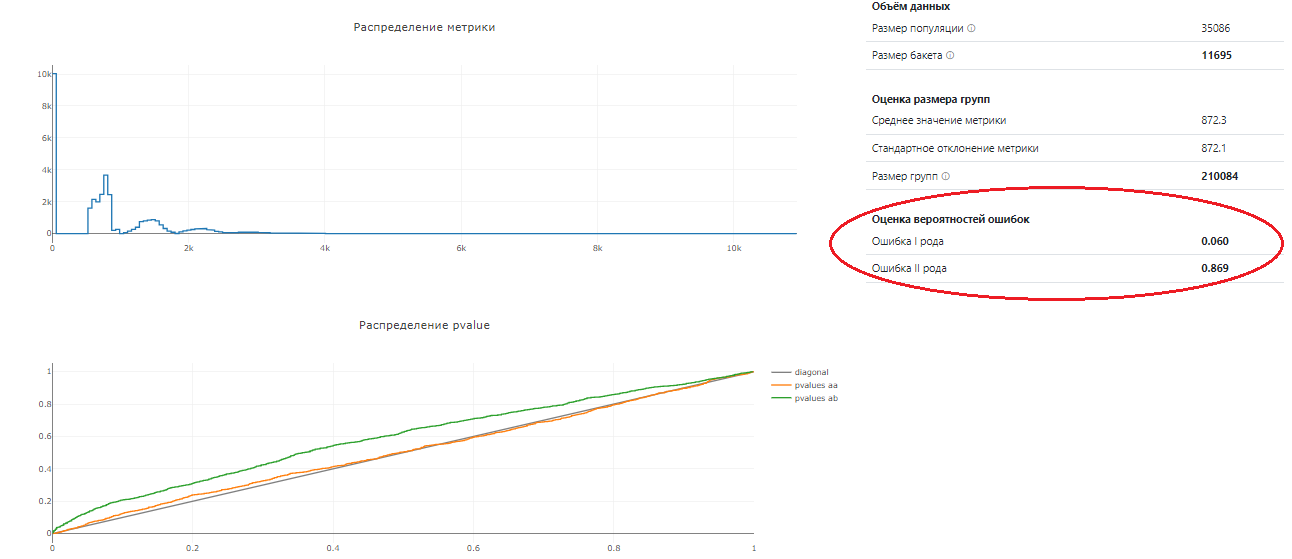

## Распределение p-value

Для более детального анализа можно построить графики распределения p-value для синтетических А/А и A/B экспериментов.\
Для этого во время синтетических экспериментов нужно не только запоминать, есть значимый эффект или нет, но и запоминать значение p-value.\
После 1000 синтетических экспериментов получим 1000 значений p-value. По этим значениям нужно построить кумулятивную гистограмму.\
Кумулятивная гистограмма — это такой график, значение которого в точке X равно доле значений в выборке, которые меньше X.\
Например, если в точке 0.2 значение равно 0.3, то  в 30% синтетических экспериментов (300 из 1000) p-value было меньше 0.2.\
 

На платформе графики распределения p-value расположены внизу отчёта на вкладке Дизайн. Пример ниже на картинке:

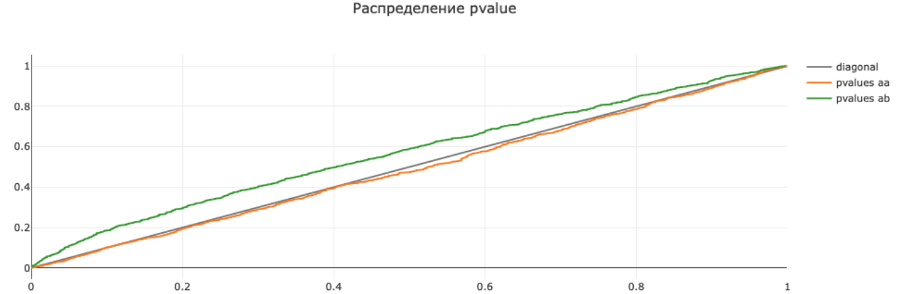

## Как пользоваться графиками распределения p-value?

Для экспериментов без эффекта (синтетические A/A эксперименты) есть теорема, согласно которой распределение p-value должно быть равномерным.\
То есть кумулятивная гистограмма должна быть близка к диагонали.\
Если график распределения сильно отклоняется от диагонали, то это сигнал о том, что в дизайне может быть ошибка и нужно его тщательно перепроверить.\
Для экспериментов с эффектом (синтетические A/Б эксперименты) распределение p-value должно быть выпуклым вверх.  Чем он более выпуклый вверх, тем лучше.\
Это говорит о том, что при наличии эффекта часто получаются малые значения p-value, а когда p-value меньше уровня значимости, тогда говорим, что есть значимый эффект.

### Вопрос 1:
По графику функции распределения p-value определите,  является ли дизайн эксперимента корректным или нет.\
Ниже дано распределение p-value для А/А тестов.

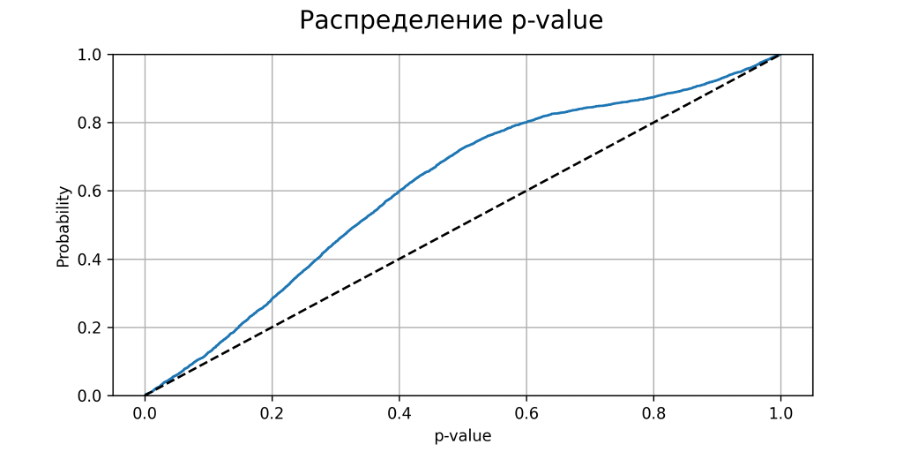

***Ответ:*** Некорректный\
Распределение p-value для А/А экспериментов не равномерное, а выпуклое

### Вопрос 2:
По графику функции распределения p-value определите,  является ли дизайн эксперимента корректным или нет.\
Ниже дано распределение p-value для А/А тестов.

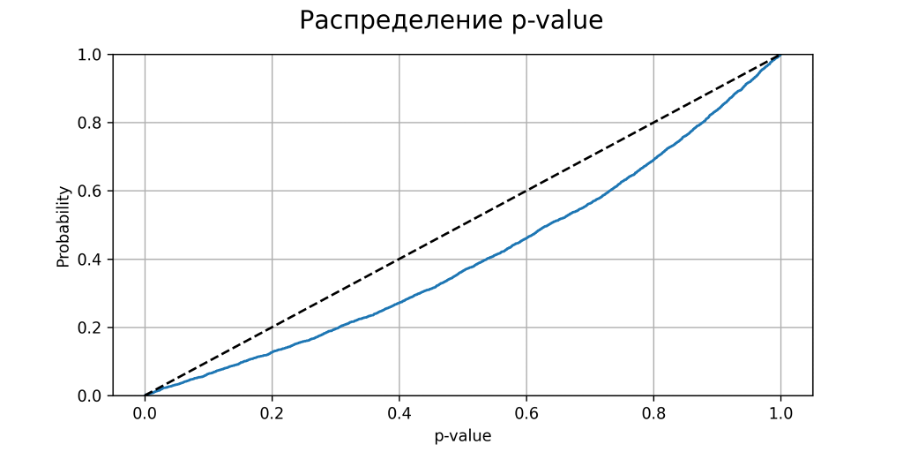

***Ответ:*** Некорректный\
распределение p-value для А/A экспериментов неравномерное

### Вопрос 3:
По графику функции распределения p-value определите,  является ли дизайн эксперимента корректным или нет.\
Ниже дано распределение p-value для А/А тестов.

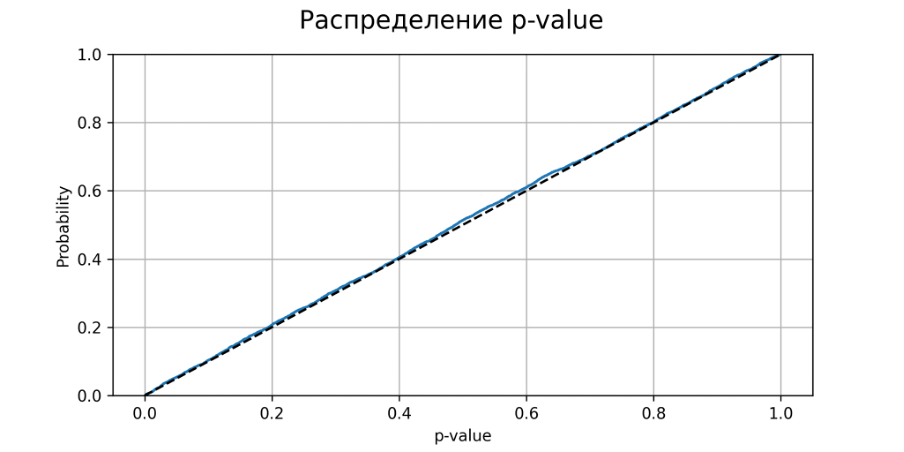

***Ответ:*** Корректный\
распределение p-value для А/A экспериментов равномерное

Также существуют специальные тесты, которые отвечают на вопрос, можем ли мы считать данное распределение равномерным.\
Это можно сделать с помощью теста Колмогорова-Смирнова или в упрощенном виде использовать критерий Пирсона.\
Но часто ответ виден на глаз, поэтому мы данной темы касаться не будем.

## Ошибки дизайна

Допустим, мы проверили дизайн эксперимента и обнаружили, что оценки вероятностей ошибок не соответствуют значениям, заявленным в дизайне.\
Что делать? Нужно искать причину, почему так происходит. Универсального алгоритма действий в этой ситуации нет.\
Вот несколько примеров ошибок в дизайне:

1. `Неудачно выбранная продолжительность эксперимента.`\
Мы уже говорили, что нужно обращать внимание на периодичность в данных и брать целое число периодов для эксперимента.

2. `Неправильное разбиение пользователей на группы.`\
Из-за ошибки в технической реализации может получиться, что в контрольной группе у нас будут одни женщины, а в экспериментальной — одни мужчины.\
Это совсем не случайное распределение пользователей, группы могут сильно отличаться своим поведением без влияния эксперимента.

3. `Зависимые данные в выборках.`\
Многие статистические тесты, в том числе и t-test, некорректно работают, когда данные выборок зависимы.\
Приведём пример зависимых данных. За время эксперимента пользователи могут совершать по несколько покупок.\
Покупки разных пользователей считаем независимыми. Покупки одного пользователя, скорее всего, зависимы.\
Если использовать в качестве данных стоимости покупок по-отдельности, то получим зависимые данные в выборках.\
Если же в качестве метрики использовать суммарные траты пользователя за время эксперимента, то на одного пользователя будет одно значение, данные будут независимы.

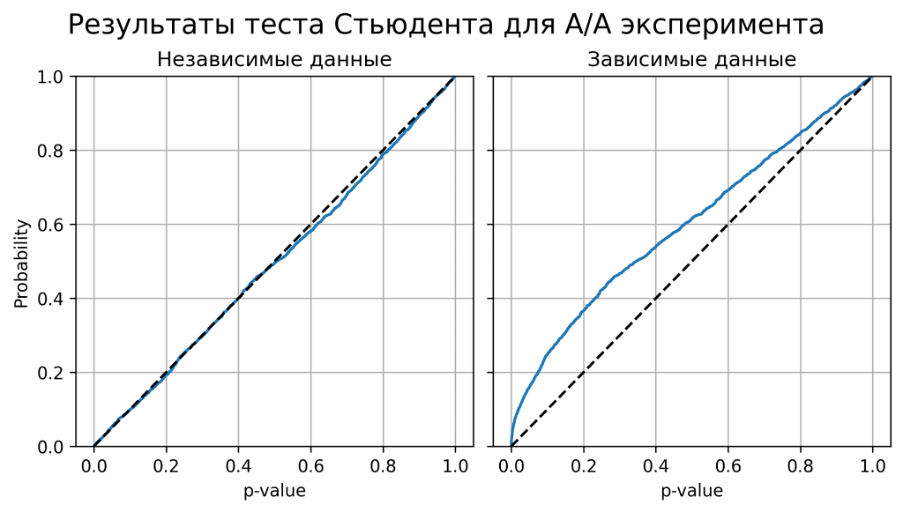

## Запуск эксперимента

Теперь мы значем, как подобрать дизайн эксперимента и проверить его корректность.\
Осталось применить эти значения на практике и запустить новый эксперимент

`Заданные параметры эксперимента:`

- `Название эксперимента` — «Refactoring backend»;
- `Метрика среднее время обработки запроса` — «response time»;
- `Период эксперимента` — с «2022-04-05» по «2022-04-12», эксперимент стартует и завершается в одно и то же время, поэтому продолжительность эксперимента при таких датах ровно 7 суток;
- `Стратификация` и `cuped` — «off», эти параметры мы изучим позже;
- `Уровень значимости` — 0.05;
- `Допустимая вероятность ошибки второго рода` — 0.1;
- `Ожидаемый эффект` — «5». На платформе использует относительный эффект, а не абсолютный.\
Это удобно для работы с положительными величинами разных размерностей.\
Эффект в 5% означает, что если среднее время загрузки равно 70 миллисекундам, то мы ожидаем эффект равный 3.5 миллисекунды;
- `Количество бакетов` — **нужно подобрать**.
 
`Количество бакетов` влияет на размер групп. А размер групп, как мы выяснили в прошлом уроке, влияет на вероятности ошибок. 
Нужно подобрать количество бакетов так, чтобы, с одной стороны, в эксперименте было задействовано минимальное количество пользователей, с другой стороны, оценка вероятности ошибки второго рода была не больше допустимой вероятности ошибки второго рода.

На платформе А/В тестирования на вкладке Дизайн реализована автоматическая оценка размера групп. 
Размер групп оценивается по формулам, которые мы разобрали в прошлом уроке. 
Чтобы определить количество бакетов, нужно выбрать максимальное количество бакетов, при котором размер бакета будет больше или равен оценке необходимого размера групп.

На картинке ниже показан пример блока с расчётами для некоторого дизайна эксперимента:

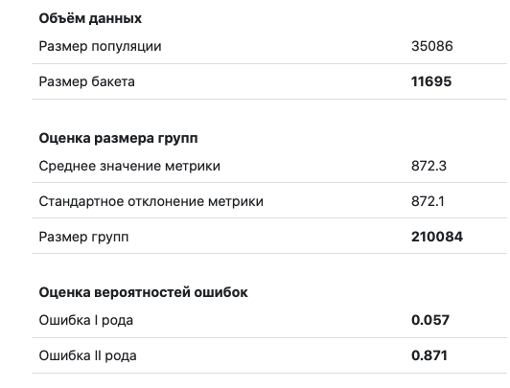

### Вопрос:
Откройте вкладку Дизайн на платформе А/Б тестирования.\
Даты начала и окончания эксперимента для проверки дизайна выберите в прошлом незадолго до эксперимента, период должен быть такой же продолжительности, что и в эксперименте.\
Установите указанные выше параметры эксперимента.  Подберите количество бакетов.

Какое количество бакетов получилось?

***Ответ:*** 13

Если вы подбираете параметры эксперимента первый раз, то у вас может возникнуть много вопросов. 
- Почему оценка вероятности ошибки I рода не равна 0.05? 
- На каком именно периоде проводить подборку параметров? 
- Что делать, если на разных периодах получаются разные результаты?

Чтобы проверка дизайна вычислялась не слишком долго, мы ограничились 1000 синтетическими A/A и A/B тестами.\
При таком количестве экспериментов, даже если всё корректно, при уровне значимости 0,05 оценка вероятности ошибки I рода может оказаться равной 0,037 или 0,065.\
Если вы получили результат, сильно отличающийся от 0,05, нужно перезапустить оценку дизайна несколько раз, чтобы проверить, случайный ли это результат или оценка вероятности ошибки всегда сильно отличается.\
Если значения оценки чаще попадают в диапазон от 0,045 до 0,055 и распределение p-value для синтетических экспериментов A/A близко к равномерному, то можно считать, что тест корректный.

Если запускать оценку дизайна на разных периодах времени, то результаты могут отличаться.\
В нашем случае вы могли получать 12 или 13 бакетов в зависимости от периода подбора.\
Мы рекомендуем проводить оценку на нескольких периодах незадолго до даты запуска эксперимент.\
Близость к дате запуска обеспечивает наибольшую схожесть с данными, которые будут в эксперименте.\
А несколько вариантов периодов позволяют сделать оценку более надёжной. Если вы получили разные оценки, то строгого алгоритма для принятия решения нет.\
Можно брать средний результат или более надёжный, с запасом. В нашем случае мы решили взять средний, равный 13 бакетам.

## Итоги

Оценить вероятности ошибок и проверить корректность дизайна можно с помощью `синтетических А/А и А/В` экспериментов на исторических данных.

Оценка вероятности `ошибки первого рода` должна быть примерно равна `уровню значимости`, а оценка вероятности `ошибки второго рода` должна быть `не больше` допустимой вероятности `ошибки второго рода`.

При корректном дизайне `распределение p-value` на синтетических А/А экспериментах должно быть `равномерным`, а для синтетических А/В экспериментов — `выпуклым вверх`.